# Titanic Advanced Machine learning
### Analystlab Africa Machine learning internship 
This notebook is for the week 5 of the analystlab africa machine learning internship.
in this notebook i will be performing exploratory data analysis, data preprocessing, model fitting, model evaluation and hyperparameter tuning.

### **About the titanic dataset**
The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

## Goal
To improve predictive performance using advanced machine learning algorithms and model optimization techniques.

Steps:
- Build Decision Tree models
- Train and evaluate Random Forest models
- Implement Gradient Boosting algorithms
- Perform Hyperparameter Tuning to improve model performance
- Compare multiple models using evaluation metrics
- Select the best-performing model based on results

## Task Breakdown
Step 1: Data Preparation
- Load your dataset.
- Handle missing values.
- Encode categorical variables if necessary.
- Split the dataset into training and testing sets.

Step 2: Build a Decision Tree Model
- Train a Decision Tree model.
- Evaluate its performance.
- Record your results.

Step 3: Build a Random Forest Model
- Train a Random Forest model.
- Evaluate its performance using appropriate metrics.
- Compare its performance with the Decision Tree model.

Step 4: Build a Gradient Boosting Model
- Train a Gradient Boosting model.
- Evaluate its performance.
- Compare it with previous models.

Step 5: Hyperparameter Tuning
Improve at least one of your models using techniques such as:
Grid Search
Random Search
Cross Validation
Examples of parameters to tune:
- Number of trees
- Maximum depth
- Learning rate
- Minimum samples split
- Number of estimators

Step 6: Model Comparison
Create a comparison table showing:
- Model Name
- Accuracy (for classification)
- Precision
- Recall
- F1-Score
- RMSE/MAE (for regression)
- Training Time (optional)
- Identify the best-performing model and explain why it performed better.

## Phase 1: Importing the needed libriaries and dataset 

In [9]:
%pip install -q dagshub mlflow

Note: you may need to restart the kernel to use updated packages.


In [10]:
# importing needed libriaries
import pandas as pd 
import numpy as np 
import mlflow
import dagshub
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [11]:
# Initialize dagshub for experiment-tracking 
dagshub.init(repo_owner='Metro', repo_name='my-first-repo', mlflow=True)

Initialized MLflow to track repo "Metro/my-first-repo"

Repository Metro/my-first-repo initialized!

In [12]:
# importing the titanic dataset
titanic_df = pd.read_csv("/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv")

In [13]:
#checking the first 5 rows in the dataset 
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Sub-Phase 1.1: what do the columns in the data mean 
Columns:     Description 

Passenger ID: This is the id of each passengers in the dataset 

Survived:     This is the target column it shows if the passenger survived or not 

Pclass:       This is the Ticket class of the ship that is (1 = 1st, 2 = 2nd, 3 = 3rd)

Name:        This is the name of the passenger 

Sex:          This is the Gender of the passenger 

Age:        This is the Age of the passenger in year 

SibSp:        This is the No. of siblings / spouses aboard the Titanic

Parch:       This is the No. of parents / children aboard the Titanic

Ticket:       This is the Ticket number of passenger

Fare:         This is the Fare paid by each passenger 


## Phase 2: Exploratry Data Analysis 

In [14]:
#checking the shape of the dataset 
shape = titanic_df.shape 

print(f" There are {shape[0]} rows and {shape[1]} columns/features in the Titanic data ")

 There are 891 rows and 12 columns/features in the Titanic data 


In [15]:
# checking the statistical distribution of the data 
display(titanic_df.describe())

print("""
Insights:
- check out the Fare column see that the max is 512 which is different from the max of every other column so we will have to 
perfom normalization on that column.if the outliers lower performace but not removed for now \n
- also we will have to remove the Passenger id cause its just a count from 1 to 891
""")

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Insights:
- check out the Fare column see that the max is 512 which is different from the max of every other column so we will have to 
perfom normalization on that column.if the outliers lower performace but not removed for now 

- also we will have to remove the Passenger id cause its just a count from 1 to 891



In [16]:
#checking for duplicate column 
print(f" The duplicated rows are: {titanic_df.duplicated().sum()}")


 The duplicated rows are: 0


In [17]:
# checking out the missing data in the dataset 
is_null_here = titanic_df.isna().sum() / len(titanic_df) * 100
is_nulldf = pd.DataFrame({"column": is_null_here.index, "Percent_missing":is_null_here.values})

display(is_nulldf)
print(f"Insights: \nwe will have to fill the age column and the Embarked column and maybe we will drop the cabin column")

,column,Percent_missing
0,PassengerId,0.000000
1,Survived,0.000000
2,Pclass,0.000000
3,Name,0.000000
4,Sex,0.000000
5,Age,19.865320
6,SibSp,0.000000
7,Parch,0.000000
8,Ticket,0.000000
9,Fare,0.000000


Insights: 
we will have to fill the age column and the Embarked column and maybe we will drop the cabin column


### Sub-Phase 2.1 statistical Relationships 
Checking the relationships between the colums 

insights: 

        In the passenger_ id to Fare and the Age to fare graph we see that we have a few outliers who have paid  500  we might remove this rows 

        
                


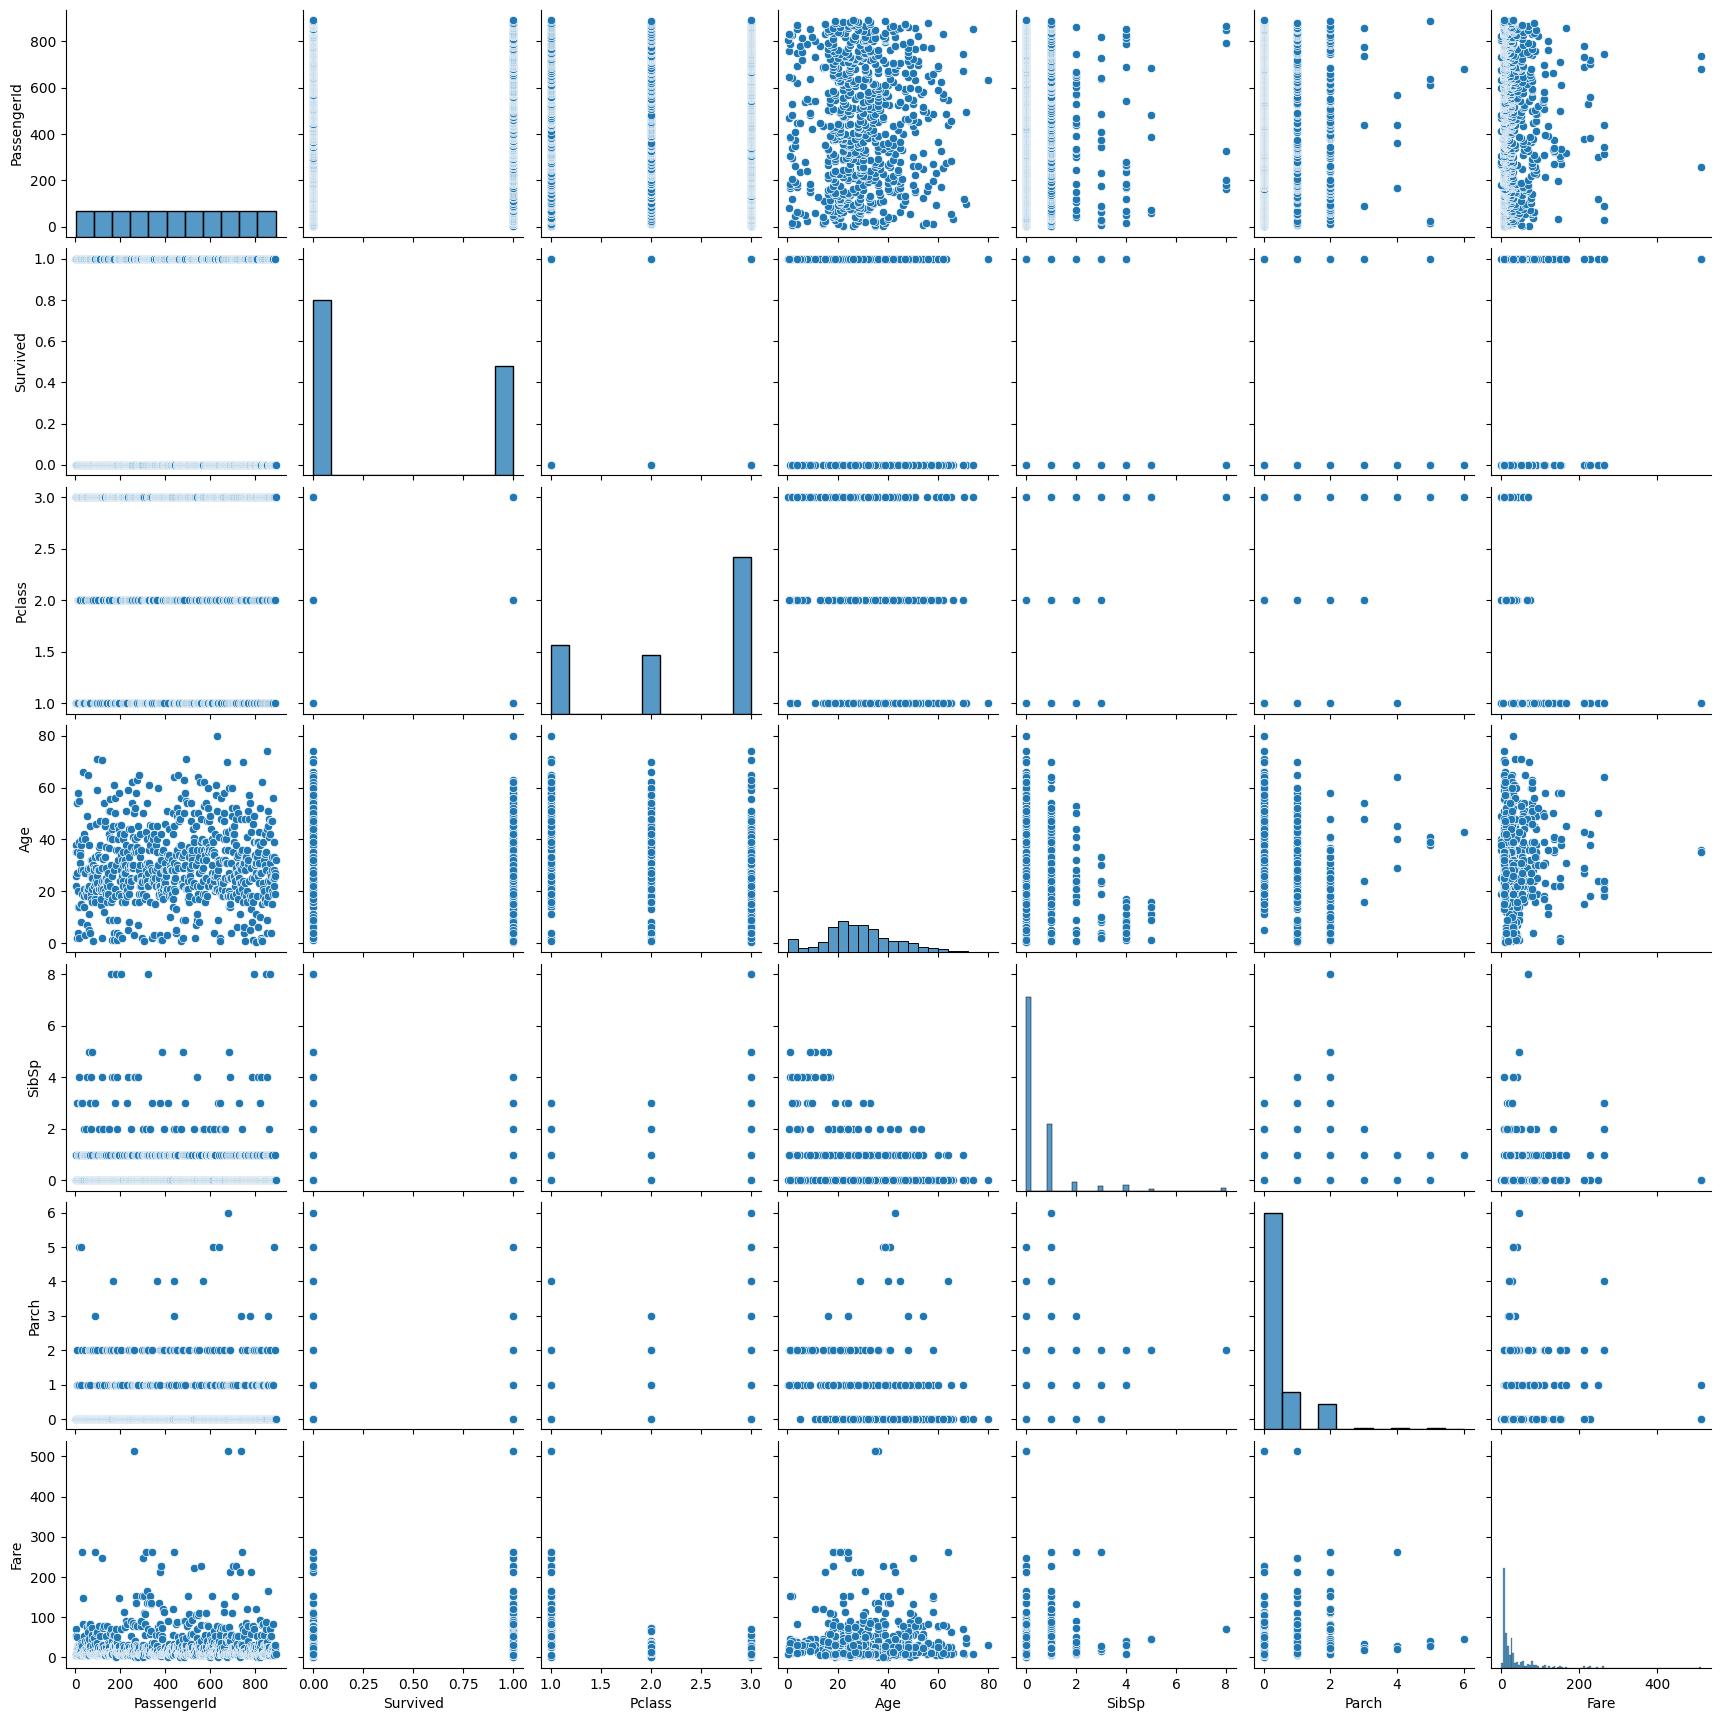

In [18]:
# firstly using seaborns pairplot to plot the overall relationships btwn columns 
sns.pairplot(titanic_df)

print("""insights: \n
        In the passenger_ id to Fare and the Age to fare graph we see that we have a few outliers who have paid  500  we might remove this rows \n
        
                """)

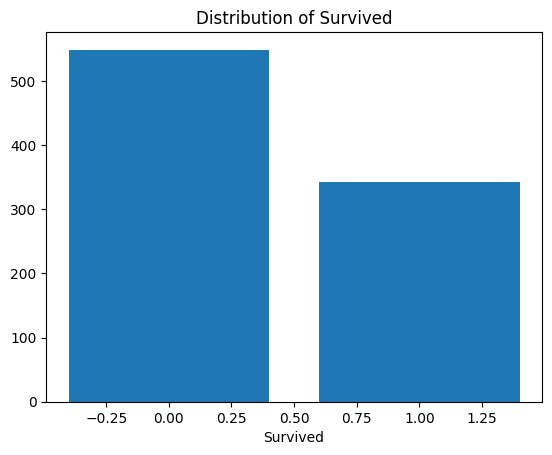

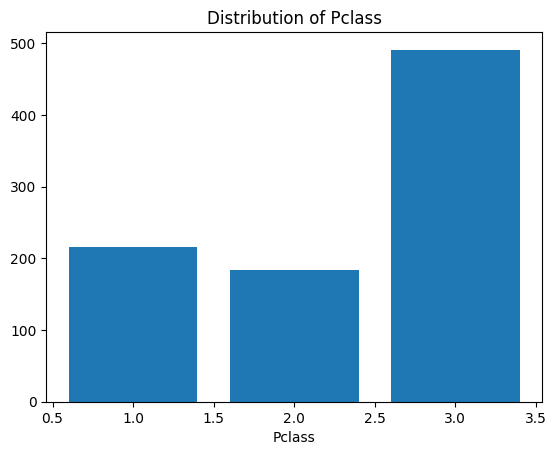

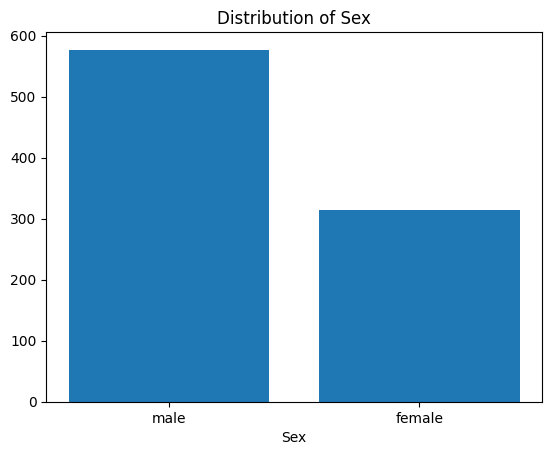

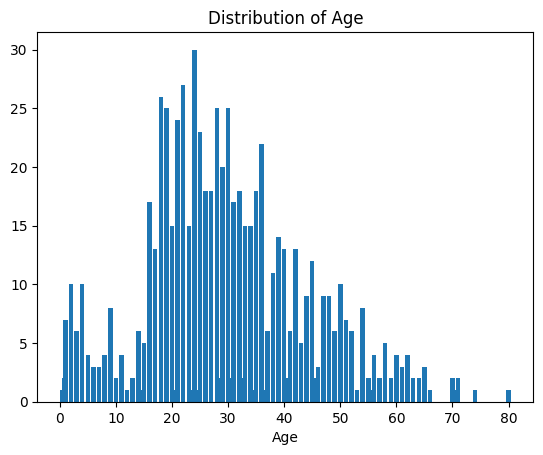

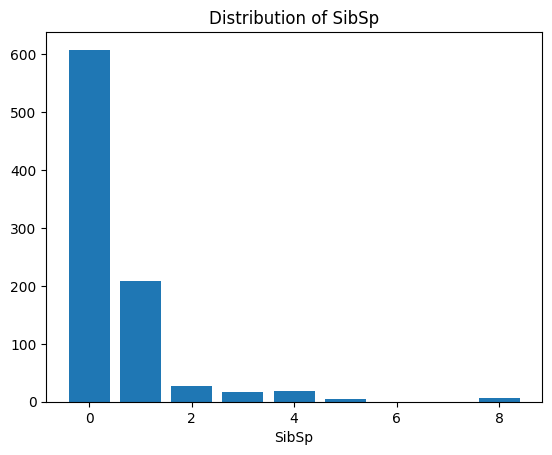

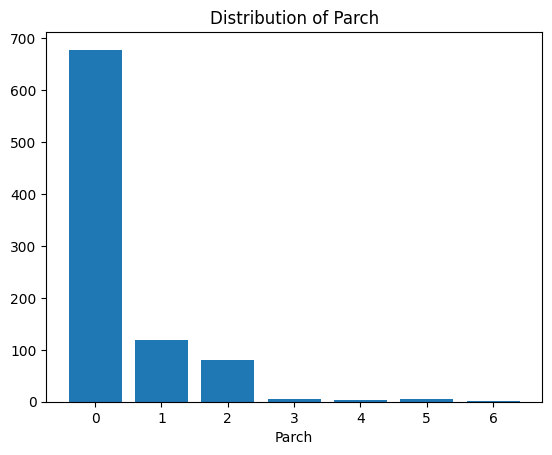

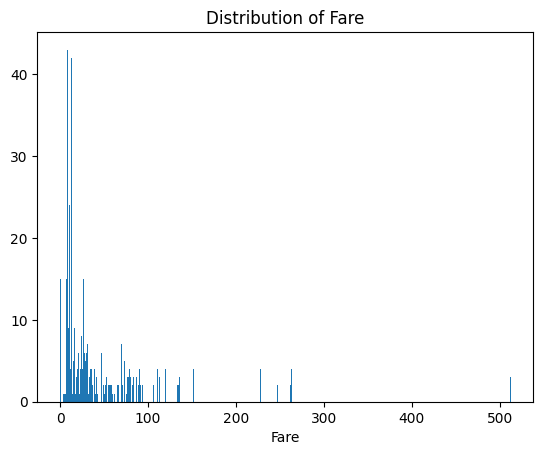

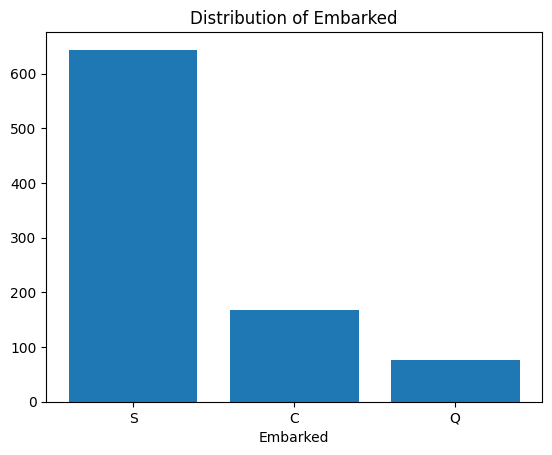


        Insights: 

        The Survived more people died than survived 

        In the Pclass there are  more people in 3rd class
        More males than females in the Sex column
        most passengers are from age 20 - 30 with some children being there also 
        most passengers dont have siblings, spouse , parents or children on the fight
        most passengers embaked from 'S'
    


In [19]:
# checking out the distribution of the data 
def plot_distribution(df, column_list):
    for column in column_list:
        df_val_counts = df[column].value_counts()
        plt.bar(df_val_counts.index, df_val_counts.values,align='center')
        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.show()

column_list = [ "Survived", "Pclass", "Sex","Age", "SibSp", "Parch", "Fare", "Embarked" ]
plot_distribution(titanic_df, column_list)

print("""
        Insights: \n
        The Survived more people died than survived \n
        In the Pclass there are  more people in 3rd class
        More males than females in the Sex column
        most passengers are from age 20 - 30 with some children being there also 
        most passengers dont have siblings, spouse , parents or children on the fight
        most passengers embaked from 'S'
    """)

### Sub-Phrase 2.1: Columns Relationships with the target column('Survived')

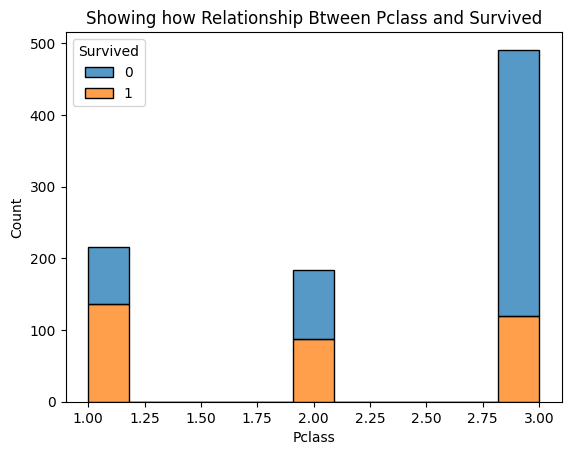

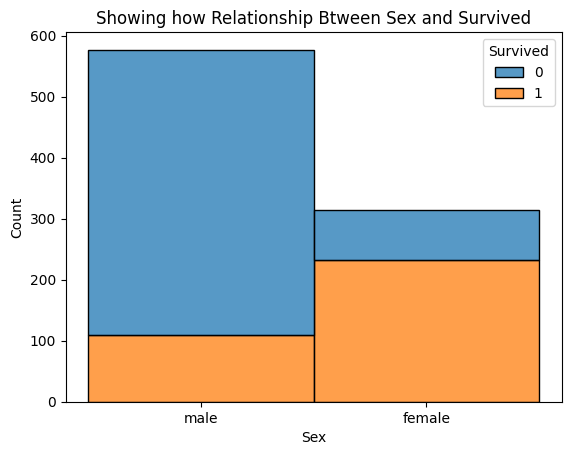

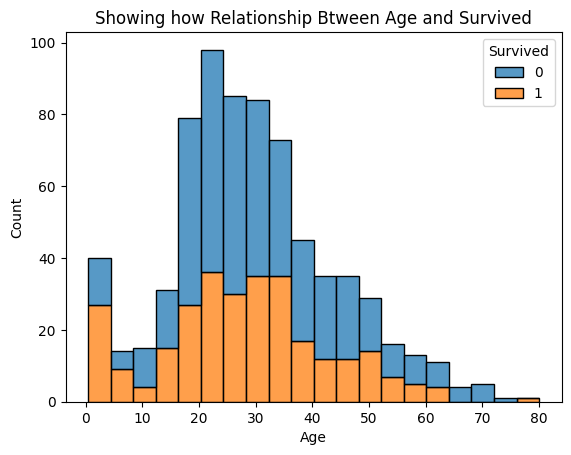

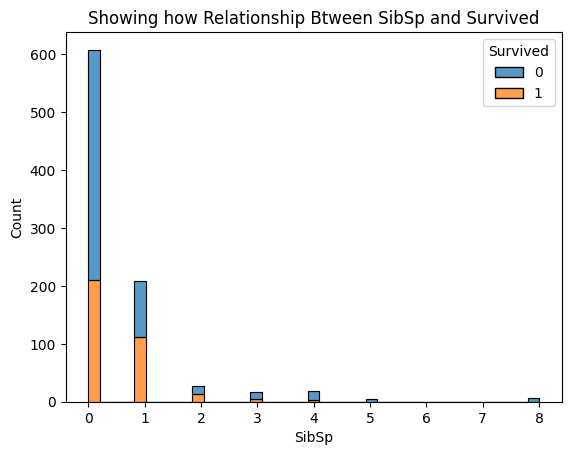

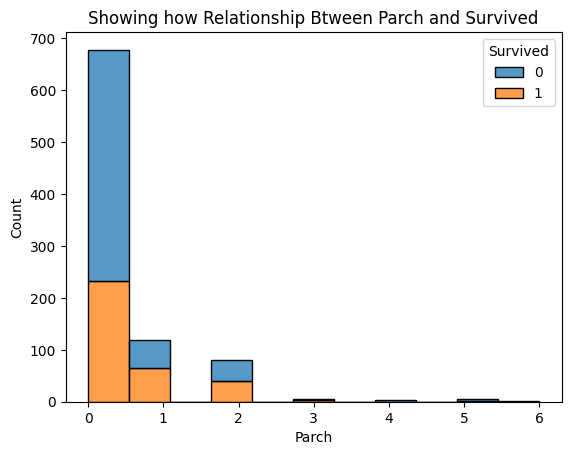

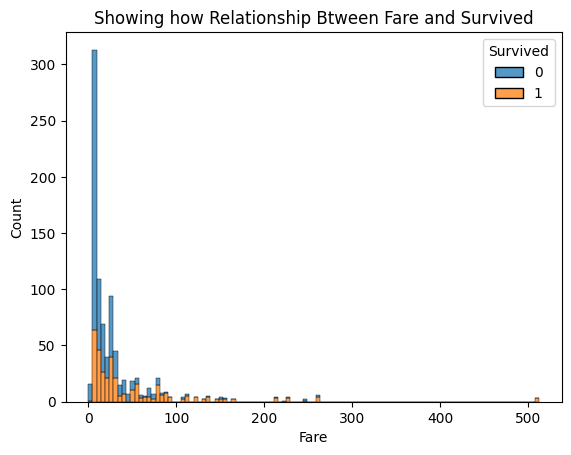

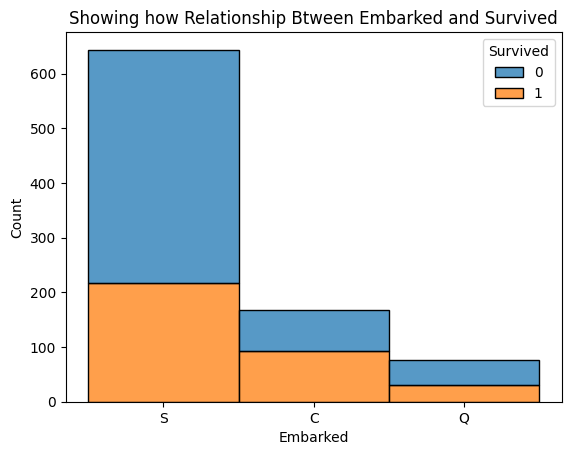


        Insight:

        More passengers in Class 1 survived 

        More Females Survived

        more siblings or spouse means death  

    


In [20]:
# checking out the distribution of the data 
def target_relationship_plot(df, column_list):
    for column in column_list:
        sns.histplot(titanic_df,x = column , hue = "Survived", multiple="stack")
        plt.title(f"Showing how Relationship Btween {column} and Survived")
        plt.show()

column_list = [ "Pclass", "Sex","Age", "SibSp", "Parch", "Fare", "Embarked" ]
target_relationship_plot(titanic_df, column_list)

print("""
        Insight:\n
        More passengers in Class 1 survived \n
        More Females Survived\n
        more siblings or spouse means death  \n
    """)

## Phase 3: Data Preprocessing 
using the insights from the previous chapters we then clean and preprocess the data 

In [21]:
## creating a function to clean and preprocess the data 
fe_drop_column_list = ["PassengerId", "Name", "Sex", "Ticket", "Cabin","family_size","SibSp","Parch"]
fe_encode_colum_list = ["Embarked","title", "family_bin"]
def find_mean(df, column):
    """
    Finds the mean of the continous colum (int,float)
    """
    return df[column].mean()

def find_mode(df,column):
    """
    Finds the mode of the categorical column (object, str)
    """
    return df[column].mode()


def create_family_size_bin(df):
    print("Feature Engineering a familysize column")
    """
    creates a column that combines and splits the Parch and SibSp column into bins 
    the sole passenger without family members 
    the small family with less than 3 members 
    the large family with more than or equal to 4 members 
    also we encode the family bin becuz we are using a linear model.
    """
    # creates familysize column combining Parch and Sibsp along with the passenger 1
    df["family_size"] = df["Parch"] + df["SibSp"] + 1
    df["family_bin"] = 0
    df.loc[(df['family_size'] >= 2) & (df['family_size'] <= 3), "family_bin"] = 1
    df.loc[(df['family_size'] >= 4), "family_bin"] = 2

    return df
    
    
def fe_clean_df(df, drop_column_list: list ,encode_colum_list: list):
    """
    Cleans the dataframe that is imputed into it 
    Arguments:
    
    """
    # Feature Engineering side 
    # change the Sex column to only is female or not (0,1)
    print("Feature Engineering the Sex column")
    df["is_female"] = (df["Sex"] == "female").astype(int)
    
    print("Feature Engineering the parch column")
    # this checks both the parents & children column and the siblings & spouse column to make sure
    df["is_alone"] = ((df["Parch"]) < 1 & (df["SibSp"]< 1)).astype(int)
    
    print("Feature Engineering a familysize column")
    df = create_family_size_bin(df)
    print("Extracting titles from the  Name column")
    # extract the titles on the names of passengers 
    df['title'] = [ln.split()[1] for ln in df["Name"].values]
    df['title'] = [title if title in ['Mr.', 'Miss.', 'Mrs.', 'Master.', 'Dr.', 'Rev.','Baron.','Master.','Mlle.'] else 'Unknown' 
                   for title in df['title'].values ]

    # Preprocessing the data 
    # fill the missing data in the Age column
    print("filling the null values in Age column")
    mean_age = find_mean(df, "Age")
    df["Age"] = df["Age"].fillna(mean_age)
    # fill the missing data in the Embarked column
    print("filling the null values in Embarked column")
    mode_embarked = find_mode(df, "Embarked")
    df["Embarked"] = df["Embarked"].fillna(mode_embarked)
    # standardize the fare column
    # sdc = StandardScaler() # did not want to standardize the Fare column
    # df["Fare"] = sdc.fit_transform(df["Fare"])

    # droping the columns that are not in use 
    print("dropping the unwanted columns")
    df_droped = df.drop(columns = drop_column_list)
    #Encoding the categorical columns 
    print("Encoding the categorical columns")
    df_dummies = pd.get_dummies(df_droped, columns = encode_colum_list, drop_first = True,dtype=int)

    return df_dummies
    

In [22]:
# using the function to clean the data 
train = titanic_df.copy()

fe_train_df = fe_clean_df(train,fe_drop_column_list,fe_encode_colum_list)

Feature Engineering the Sex column
Feature Engineering the parch column
Feature Engineering a familysize column
Feature Engineering a familysize column
Extracting titles from the  Name column
filling the null values in Age column
filling the null values in Embarked column
dropping the unwanted columns
Encoding the categorical columns


In [23]:
# a peek into the clean dataset 
fe_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Age            891 non-null    float64
 3   Fare           891 non-null    float64
 4   is_female      891 non-null    int64  
 5   is_alone       891 non-null    int64  
 6   Embarked_Q     891 non-null    int64  
 7   Embarked_S     891 non-null    int64  
 8   title_Master.  891 non-null    int64  
 9   title_Miss.    891 non-null    int64  
 10  title_Mlle.    891 non-null    int64  
 11  title_Mr.      891 non-null    int64  
 12  title_Mrs.     891 non-null    int64  
 13  title_Rev.     891 non-null    int64  
 14  title_Unknown  891 non-null    int64  
 15  family_bin_1   891 non-null    int64  
 16  family_bin_2   891 non-null    int64  
dtypes: float64(2), int64(15)
memory usage: 118.5 KB


In [24]:
# firstly we separate the cleaned data to X(inputs) and y (target)
fe_y = fe_train_df["Survived"]
fe_X = fe_train_df.drop(["Survived"], axis = 1)

# then we split the data into train data 70% and training data 30%
X_train,X_test,y_train, y_test = train_test_split(fe_X,fe_y,test_size = 0.3, random_state = 43)

# checking the shape 
print(f"The shape of train set is X_train: {X_train.shape} and y_train {y_train.shape}\n")
print(f"The shape of train set is X_test: {X_test.shape} and y_test {y_test.shape}")

The shape of train set is X_train: (623, 16) and y_train (623,)

The shape of train set is X_test: (268, 16) and y_test (268,)


## Phase 4: Model Fitting with Feature Engineering
The feature engineering done in the normal clean process was good but what if we are able to add more features.
using the same logistic regression can we get a better accuracy score?

"what better way to work than to work on the data"

i will be using mlflow tracking to track the experiments so i can collate all the accuracy scores 

### Setting up Mlflow 
mlflow is a library that we can use to track the models we built, thier evaluation and so many other things 
using mlflow will make it easier to track all the models i will be building 

In [25]:
mlflow.set_experiment("Week 5 Analystlab-africa titanic dataset")
mlflow.start_run(run_name = "Global_baseline_run")


<ActiveRun: >

In [26]:

def log_model(model, name, accuracy ,tp,tn,fp,fn, tag):
    """
    Function makes it easy to log all the accuracy and confusion matrics of all the models
    """
    # Log the model
    mlflow.sklearn.log_model(sk_model = model, name = name)
    # Predict on the test set, compute and log the loss metric

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("true_positive", tp)
    mlflow.log_metric("true_negative", tn)
    mlflow.log_metric("false_positive", fp)
    mlflow.log_metric("false_negative", fn)

    # Optional: Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", tag)
    # this is to diffenrentaite the models in mlflow ui 
    mlflow.log_param("model_name", name)
    

### Sub-Phase 4.0: Logistic Regression Baseline
we shall be training a baseline Logistic Regression in this sub-phase and using mlflow to track the accuracy and confusion matrix scores 


In [27]:
def estimate_metric(y_test, model_pred, model_name):
    """
    calculates the accuracy and returns it then also displays the confusion matrix 
    """
    # now we assess the prediction using accuracy score
    accuracy_prediction = accuracy_score(y_test, model_pred)
    print(f"The accuracy score of the {model_name} is {accuracy_prediction} \n ")
    
    # we use confusion matrix to check the tp,tn,fp,fn 
    confusion_matrix_ = confusion_matrix(y_test, model_pred)
    true_positive = confusion_matrix_[0][0]
    true_negative = confusion_matrix_[1][1]
    false_positive = confusion_matrix_[0][1]
    false_negative = confusion_matrix_[1][0]
    
    # we display the confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_test,model_pred)
    
    # we return the metrics for logging 
    return accuracy_prediction, true_positive, true_negative, false_positive, false_negative

The accuracy score of the baseline_logistic_reg is 0.7985074626865671 
 


2026/06/06 21:26:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Baseline_logistic_regression at: https://dagshub.com/Metro/my-first-repo.mlflow/#/experiments/0/runs/3963f404675c4c218eb746983e7ef9fe
🧪 View experiment at: https://dagshub.com/Metro/my-first-repo.mlflow/#/experiments/0


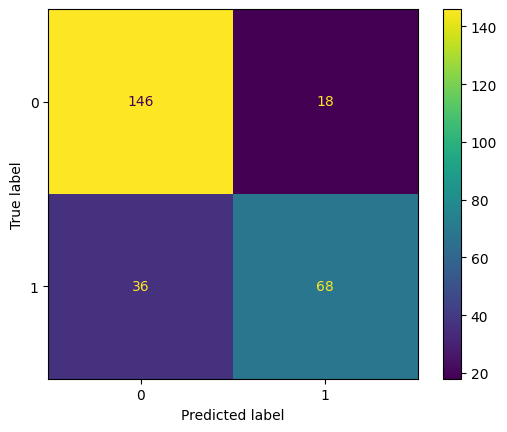

In [28]:
mlflow.start_run(run_name = "Baseline_logistic_regression", nested = True)
# firstly we instantiate the model 
log_regmfe = LogisticRegression(max_iter = 500)


# then we fit the model on the training data 
log_regmfe.fit(X_train, y_train)

# then we use the fitted model to predict if a passenger suvived or not 
log_pred = log_regmfe.predict(X_test)

# Use the estimate_metric function
log_acc_fe,tp,tn,fp,fn = estimate_metric(y_test, log_pred, "baseline_logistic_reg")

tag = "Baseline logistic model with param n_iter = 400"
# log everything using mlflow
log_model(log_regmfe, "logistic_reg_titanic", log_acc_fe, tp, tn, fp, fn, tag)

mlflow.end_run()

In [29]:
def plot_coef(model, train_df):
    """
    uses the logistic regression coef_ to plot feature importance 
    positive features are more indicative that a passenger survived and negative didnt survive
    """
    #extract the coef of the columns
    coefs = model.coef_
    # intercept = model.intercept_
    #extract the column names
    feature_list = X_train.columns.to_list()
    #create a dataframe for the coefs linking the name to their variables
    coef_importance = pd.DataFrame({"features": feature_list,"coeficent_weights":coefs[0] })
    # sort the coefs
    coef_importance = coef_importance.sort_values(by = "coeficent_weights", ascending = True)
    # plot the coefs
    coef_importance.plot(x = "features", y ="coeficent_weights", kind = 'barh')
    plt.title("coeficent weights of columns")
    plt.xlabel("Coeficent weights")
    plt.show()

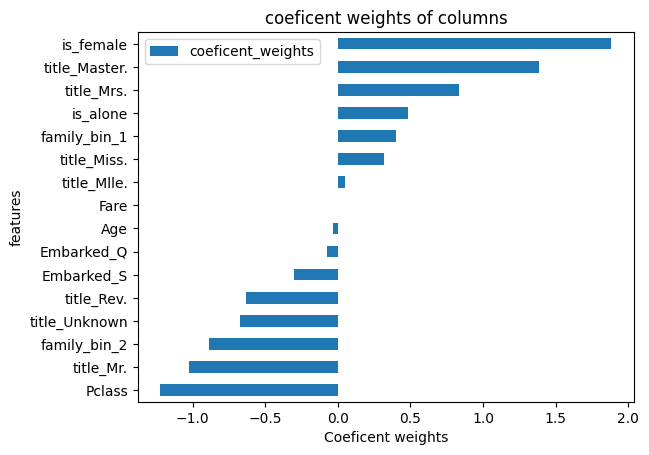

In [30]:
plot_coef(log_regmfe,X_train)

### Sub-Phase 4.1: Decision Tree Classifer Baseline
this is the baseline model for the decision tree classifier, along with metrics 

The accuracy score of the baseline_decision_tree_classifier is 0.7649253731343284 
 


2026/06/06 21:26:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Baseline_Decision_tree_classifier at: https://dagshub.com/Metro/my-first-repo.mlflow/#/experiments/0/runs/75ff03cecc5646c2be1b9e5accd6f58d
🧪 View experiment at: https://dagshub.com/Metro/my-first-repo.mlflow/#/experiments/0


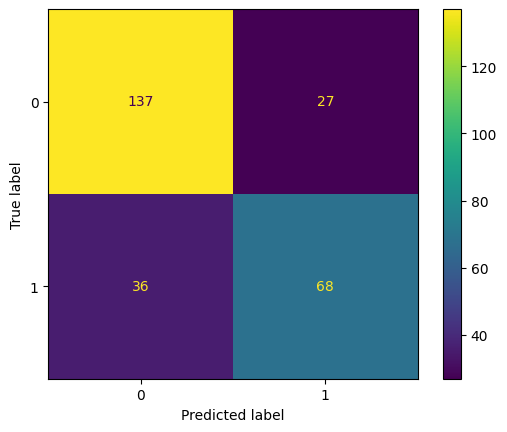

In [31]:
mlflow.start_run(run_name = "Baseline_Decision_tree_classifier", nested = True)
# instantiating the decision tree classifier as it is a baseline model we would not add any parameters
dec_tres_class = DecisionTreeClassifier()

# Fitting the model to the dataset 
dec_tres_class.fit(X_train, y_train)

# predicting on the X_test 
dec_tres_pred = dec_tres_class.predict(X_test)

# estimating baseline model performance
dec_tres_acc, tp, tn, fp, fn = estimate_metric(y_test, dec_tres_pred, "baseline_decision_tree_classifier")

tag = "Baseline decision tree classifier"

# log everything to mlflow
log_model(dec_tres_class, "baseline_Decision_tree_classifier_titanic", dec_tres_acc, tp, tn, fp, fn, tag)

mlflow.end_run()

### Sub-Phase 4.2: Baseline Random forest classifier

The accuracy score of the baseline_random_forest_classifier is 0.7835820895522388 
 


2026/06/06 21:27:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Baseline_random_forest_classifer at: https://dagshub.com/Metro/my-first-repo.mlflow/#/experiments/0/runs/52ee993b35df4897bf45b6c2e4407b0f
🧪 View experiment at: https://dagshub.com/Metro/my-first-repo.mlflow/#/experiments/0


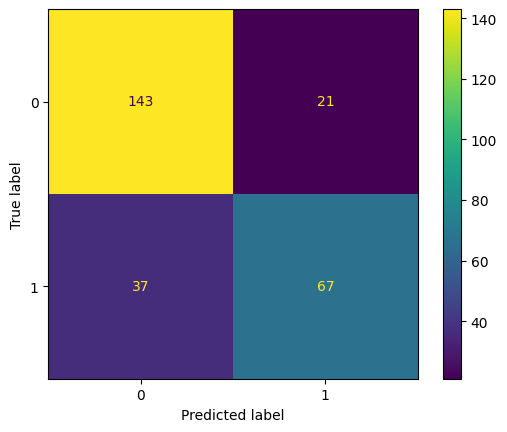

In [32]:
mlflow.start_run(run_name = "Baseline_random_forest_classifer", nested = True)
# instantiating the random Forest Classifier as it is a baseline model we would not add any parameters
rand_forest_class = RandomForestClassifier()

# Fitting the model to the dataset 
rand_forest_class.fit(X_train, y_train)

# predicting on the X_test 
rand_forest_pred = rand_forest_class.predict(X_test)

# estimating baseline model performance
rand_forest_acc, tp, tn, fp, fn = estimate_metric(y_test, rand_forest_pred, "baseline_random_forest_classifier")

tag = "Baseline random forest classifier"

log_model(rand_forest_class, "baseline_Random_forest_classifier_titanic", rand_forest_acc, tp, tn, fp, fn, tag)


mlflow.end_run()

### Sub-Phase 4.3: Baseline Gradeint booosting classifier (Xgboost)

The accuracy score of the baseline_xgboost_classifier is 0.8022388059701493 
 


2026/06/06 21:28:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Baseline_Xgboost_classifier at: https://dagshub.com/Metro/my-first-repo.mlflow/#/experiments/0/runs/1d34aee55b224f51a4fdacb47b0330df
🧪 View experiment at: https://dagshub.com/Metro/my-first-repo.mlflow/#/experiments/0


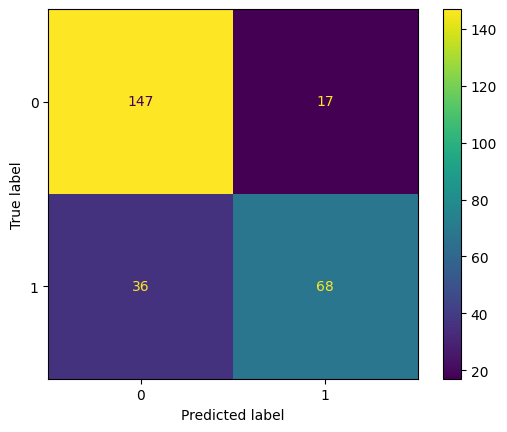

In [33]:
mlflow.start_run(run_name = "Baseline_Xgboost_classifier", nested = True)
# instantiating the Xgboost Classifier as it is a baseline model we would not add any parameters
xgb_classifier = XGBClassifier()

# Fitting the model to the dataset 
xgb_classifier.fit(X_train, y_train)

# predicting on the X_test 
xgb_classifier_pred = xgb_classifier.predict(X_test)

# estimating baseline model performance
xgb_classifier_acc, tp, tn, fp, fn = estimate_metric(y_test, xgb_classifier_pred, "baseline_xgboost_classifier")


tag = "Baseline random forest classifier"

log_model(xgb_classifier, "baseline_Xgboosts_classifier_titanic", xgb_classifier_acc, tp, tn, fp, fn, tag)

mlflow.end_run()

In [34]:
mlflow.end_run()

🏃 View run Global_baseline_run at: https://dagshub.com/Metro/my-first-repo.mlflow/#/experiments/0/runs/bd152868414e4f7bbeae07146f7bcc80
🧪 View experiment at: https://dagshub.com/Metro/my-first-repo.mlflow/#/experiments/0


## Baseline model performance comparison

>NOTE: On Metrics Reproducibility the metrics of some models are not always the same and might vary with the result shown bellow this is expected behaviour for said models and does not indicate methological difference.

#### Accuracy comparision per model (scatterplot)
![accuracy_comparison image](https://res.cloudinary.com/dvcojf8da/image/upload/v1780778724/accuracy_perm_mdmky7.png)

The Xgboost model is the best performing baseline model followed by the logistic regression model then the random forest classifier model 
the data was feature engineered with linear models in mind but with some hyper parameter tuning we can get decision model to a better score.

#### True positive comparision per model (Scatterplot)
![True positive comparison image](https://res.cloudinary.com/dvcojf8da/image/upload/v1780778997/tp_per_m_2_n8kyjt.png)

#### True negative comparision per model (Scatterplot)
![True negative comparison image ](https://res.cloudinary.com/dvcojf8da/image/upload/v1780778724/tn_per_m_vhujnx.png)


### Phase 5: Hyperparameter tunining for Xgboost model 
in this Phase we will be tuning the parameters of the Decision tree model 
we will be using RandomSearchCV

In [45]:
# setting our paramenters 
params = {
    "max_depth" :[2,5,7,10,15,20,25,50,100 ],
    "min_samples_split":[2,3,4,5],
    "min_samples_leaf":[1,2,3,4,5],
         }

# setting the model
Dtres_model = DecisionTreeClassifier(class_weight = "balanced")

# instantiating  randomSearchcv 
randomcv = RandomizedSearchCV(Dtres_model, params,n_iter = 20, random_state = 43 )

rand_search = randomcv.fit(X_train, y_train)

print(rand_search.best_params_)

{'min_samples_split': 4, 'min_samples_leaf': 5, 'max_depth': 5}


The accuracy score of the baseline_decision_tree_classifier is 0.7910447761194029 
 


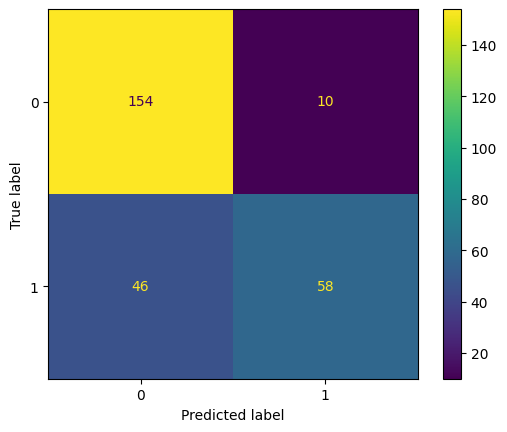

In [47]:
# instantiating the decision tree classifier as it is a baseline model we would not add any parameters
dec_tres_class = DecisionTreeClassifier(min_samples_split = 4, min_samples_leaf =  5, max_depth =  5)

# Fitting the model to the dataset 
dec_tres_class.fit(X_train, y_train)

# predicting on the X_test 
dec_tres_pred = dec_tres_class.predict(X_test)

# estimating baseline model performance
dec_tres_acc, tp, tn, fp, fn = estimate_metric(y_test, dec_tres_pred, "baseline_decision_tree_classifier")

#### Insight
even though the tuning is light and random search searches the best parameters randomly there was a significant boost in score from the Baseline model.